# Research QuantBook: Option Wheel Strategy## ObjectifAnalyser la strategie "Wheel" sur SPY qui genere du revenu par la vente alternee de puts et de calls.## Strategie- **Phase 1 (Cash)**: Vendre des puts OTM (~5% OTM, 21 DTE)  - Si assigne -> recevoir 100 shares SPY  - Sinon -> garder le premium- **Phase 2 (Detient SPY)**: Vendre des calls OTM (~5% OTM, 21 DTE)  - Si assigne -> vendre les shares, retour Phase 1  - Sinon -> garder le premium- **VIX Filter**: 15 < VIX < 20 (eviter volatilite extreme)- **Exposition max**: 80% du portefeuille## Performance de referenceSharpe ~0.8-1.0 (2019-2025) avec VIX filter optimise.## Hypotheses a tester1. OTM threshold: 3%, 5%, 7%2. DTE: 14, 21, 30 jours3. VIX filter: (12/18), (15/20), (18/25)## Prerequis- Environnement Lean Research- Donnees SPY + VIX (ou approximation)- Duree estimee: ~10 minutes## NoteLes options completes ne sont pas disponibles dans QuantBook. Ce notebook utiliseune approximation du premium basee sur Black-Scholes.Si le VIX (donnees CBOE) n'est pas disponible dans le Docker, une approximationbasee sur la volatilite historique de SPY est utilisee a la place.

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.stats import norm
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()
print("QuantBook initialisé.")

QuantBook initialisé.


## 1. Chargement des données

On charge les données SPY et le VIX pour la période 2019-2026.

In [2]:
# SPY underlyingspy = qb.add_equity("SPY", Resolution.DAILY)# VIX (via CBOE data) - peut ne pas etre disponible en Dockervix_available = Truetry:    vix = qb.add_data(CBOE, "VIX", Resolution.DAILY)except Exception:    vix_available = False    print("VIX CBOE non disponible, utilisation d'une approximation basee sur SPY.")# Charger l historique (2019-2026)start = datetime(2019, 1, 1)end = datetime(2026, 1, 1)spy_history = qb.history(spy.symbol, start, end, Resolution.DAILY)print(f"Donnees SPY: {len(spy_history)} lignes")if vix_available:    vix_history = qb.history(vix.symbol, start, end, Resolution.DAILY)    print(f"Donnees VIX: {len(vix_history)} lignes")    if len(vix_history) == 0:        vix_available = False        print("VIX historique vide, utilisation de l'approximation.")

Chargement des données historiques du VIX via qb.add_index pour filtrer les régimes de forte volatilité.

In [3]:
# Preparer les donneesspy_close = spy_history['close']if vix_available:    vix_close = vix_history['close']else:    # Approximation du VIX: volatilite historique annualisee de SPY x 100    spy_returns = spy_close.pct_change()    vix_approx = spy_returns.rolling(21).std() * np.sqrt(252) * 100    vix_close = vix_approx# Aligner les datesdata = pd.DataFrame({    'SPY': spy_close,    'VIX': vix_close}).dropna()print(f"Periode: {data.index[0].date()} a {data.index[-1].date()}")print(f"Donnees: {len(data)} jours de trading")print(f"\nStatistiques SPY:")print(f"  Prix initial: ${data['SPY'].iloc[0]:.2f}")print(f"  Prix final: ${data['SPY'].iloc[-1]:.2f}")print(f"  Return total: {(data['SPY'].iloc[-1]/data['SPY'].iloc[0] - 1):.1%}")

## 2. Approximation du premium d'options

Black-Scholes simplifié pour estimer le premium des puts et calls.

In [4]:
def estimate_option_premium(spy_price, vix, days_to_expiry, 
                             otm_pct=0.05, option_type='put'):
    """
    Estime le premium d'une option via Black-Scholes.
    
    Parameters:
    - spy_price: Prix actuel SPY
    - vix: Volatilité implicite (en points)
    - days_to_expiry: Jours jusqu'à expiration
    - otm_pct: % OTM pour le strike
    - option_type: 'put' ou 'call'
    """
    # Volatilité annualisée
    vol = vix / 100.0
    
    # Temps en années
    t = days_to_expiry / 365.0
    
    # Strike OTM
    if option_type == 'put':
        strike = spy_price * (1 - otm_pct)
    else:
        strike = spy_price * (1 + otm_pct)
    
    # Taux sans risque
    r = 0.05
    
    # Black-Scholes
    d1 = (np.log(spy_price / strike) + (r + 0.5 * vol**2) * t) / (vol * np.sqrt(t))
    d2 = d1 - vol * np.sqrt(t)
    
    if option_type == 'put':
        premium = strike * np.exp(-r * t) * norm.cdf(-d2) - spy_price * norm.cdf(-d1)
    else:
        premium = spy_price * norm.cdf(d1) - strike * np.exp(-r * t) * norm.cdf(d2)
    
    return max(0, premium)

# Test de la fonction
test_price = 450.0
test_vix = 18.0
test_dte = 21

put_premium = estimate_option_premium(test_price, test_vix, test_dte, 0.05, 'put')
call_premium = estimate_option_premium(test_price, test_vix, test_dte, 0.05, 'call')

print(f"Premium estimé pour SPY=${test_price}, VIX={test_vix}, DTE={test_dte}:")
print(f"  Put (5% OTM): ${put_premium:.2f}")
print(f"  Call (5% OTM): ${call_premium:.2f}")
print(f"\nPut en % du sous-jacent: {(put_premium/test_price)*100:.1f}%")

Premium estimé pour SPY=$450.0, VIX=18.0, DTE=21:
  Put (5% OTM): $0.95
  Call (5% OTM): $1.47

Put en % du sous-jacent: 0.2%


### Interprétation: Premium Wheel

- **VIX élevé** → Premium plus élevé (avantageux pour le vendeur)
- **OTM 5%** → Strike standard pour la stratégie wheel
- **DTE 21** → ~30 jours (mensuel)

La stratégie wheel génère du revenu régulier en vendant des options OTM.

## 3. Backtest Wheel Strategy

Simulation de la stratégie wheel avec:
- Phase 1: Vendre puts quand cash
- Phase 2: Vendre calls quand détient SPY
- VIX filter: 15-20 (éviter extrêmes)
- Exposition max: 80%

In [5]:
def backtest_wheel(data, 
                   otm_pct=0.05,
                   days_to_expiry=21,
                   vix_min=15, vix_max=20,
                   max_exposure=0.80):
    """
    Backtest Wheel Strategy sur SPY.
    """
    portfolio_values = [1.0]
    cash = 1.0  # Normalisé à 1
    shares = 0
    
    # Position options
    short_put_active = False
    short_call_active = False
    option_strike = 0.0
    option_premium = 0.0
    option_days_left = 0
    
    # Stats
    puts_sold = 0
    calls_sold = 0
    assignments = 0
    premium_collected = 0
    
    warmup = 50
    
    for i in range(warmup, len(data)):
        spy_price = data['SPY'].iloc[i]
        vix = data['VIX'].iloc[i]
        
        # Valeur du portefeuille
        port_value = cash + shares * spy_price
        
        # Gestion options courantes
        if short_put_active:
            # Estimer valeur actuelle du put
            current_dte = max(1, option_days_left - 1)
            current_premium = estimate_option_premium(spy_price, vix, current_dte, otm_pct, 'put')
            
            # Check expiration/assignment
            if current_dte <= 1 or spy_price < option_strike:
                # Assignment ou expiration
                if spy_price < option_strike:
                    # Assignment: acheter 100 shares au strike
                    cost = option_strike * 100
                    if cash >= cost:
                        cash -= cost
                        shares += 100
                        assignments += 1
                    pnl = option_premium - max(0, option_strike - spy_price)  # Simplifié
                else:
                    # Expire worthless: garder le premium
                    pnl = option_premium
                
                cash += pnl
                premium_collected += pnl
                short_put_active = False
                option_days_left = 0
            else:
                # Mark-to-market
                port_value -= current_premium  # Position short
                option_days_left = current_dte
        
        elif short_call_active:
            # Estimer valeur actuelle du call
            current_dte = max(1, option_days_left - 1)
            current_premium = estimate_option_premium(spy_price, vix, current_dte, otm_pct, 'call')
            
            # Check expiration/assignment
            if current_dte <= 1 or spy_price > option_strike:
                # Assignment ou expiration
                if spy_price > option_strike:
                    # Assignment: vendre 100 shares au strike
                    if shares >= 100:
                        cash += option_strike * 100
                        shares -= 100
                        assignments += 1
                    pnl = option_premium - max(0, spy_price - option_strike)  # Simplifié
                else:
                    # Expire worthless: garder le premium
                    pnl = option_premium
                
                cash += pnl
                premium_collected += pnl
                short_call_active = False
                option_days_left = 0
            else:
                # Mark-to-market
                port_value -= current_premium  # Position short
                option_days_left = current_dte
        
        # Vendre nouvelle option si aucune position active
        if not short_put_active and not short_call_active:
            # VIX filter
            if vix < vix_min or vix > vix_max:
                portfolio_values.append(port_value / data['SPY'].iloc[warmup])
                continue
            
            if shares == 0:
                # Phase 1: Vendre put
                premium = estimate_option_premium(spy_price, vix, days_to_expiry, otm_pct, 'put')
                if premium > 0.50:
                    # Check exposition max (100 * strike)
                    required = spy_price * (1 - otm_pct) * 100
                    if required <= cash * max_exposure:
                        short_put_active = True
                        option_premium = premium
                        option_strike = spy_price * (1 - otm_pct)
                        option_days_left = days_to_expiry
                        puts_sold += 1
            else:
                # Phase 2: Vendre call (couvert par les shares)
                contracts = shares // 100
                if contracts > 0:
                    premium = estimate_option_premium(spy_price, vix, days_to_expiry, otm_pct, 'call')
                    if premium > 0.50:
                        short_call_active = True
                        option_premium = premium
                        option_strike = spy_price * (1 + otm_pct)
                        option_days_left = days_to_expiry
                        calls_sold += 1
        
        portfolio_values.append(port_value / data['SPY'].iloc[warmup])
    
    # Métriques
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values[1:], index=data.index[warmup:])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(252) if len(returns) > 1 else 0
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'puts_sold': puts_sold,
        'calls_sold': calls_sold,
        'assignments': assignments,
        'premium_collected': premium_collected
    }

print("Fonction de backtest définie.")

Fonction de backtest définie.


## 4. Test du OTM threshold

In [6]:
# Test différents OTM thresholds
otm_values = [0.03, 0.05, 0.07]

print(f"{'OTM':<8} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'Puts':>8}")
print("-" * 48)

otm_results = {}
for otm in otm_values:
    r = backtest_wheel(data, otm_pct=otm)
    otm_results[f"{otm*100:.0f}%"] = r
    print(f"{otm*100:.0f}%{'':<6} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['puts_sold']:>8}")

best_otm = max(otm_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleur OTM: {best_otm[0]} (Sharpe={best_otm[1]['sharpe']:.3f})")

OTM        Sharpe     CAGR    MaxDD     Puts
------------------------------------------------


NameError: name 'data' is not defined

## 5. Test du DTE

In [7]:
# Test différents DTE
dte_values = [14, 21, 30]

print(f"{'DTE':<8} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'Trades':>8}")
print("-" * 48)

dte_results = {}
for dte in dte_values:
    r = backtest_wheel(data, days_to_expiry=dte)
    dte_results[f"{dte}j"] = r
    print(f"{dte}{'':<7} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['puts_sold']+r['calls_sold']:>8}")

best_dte = max(dte_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleur DTE: {best_dte[0]} (Sharpe={best_dte[1]['sharpe']:.3f})")

DTE        Sharpe     CAGR    MaxDD   Trades
------------------------------------------------


NameError: name 'data' is not defined

## 6. Test du filtre VIX

In [8]:
# Test différentes plages VIX
vix_ranges = [
    ((12, 18), "VIX12/18"),
    ((15, 20), "VIX15/20"),
    ((18, 25), "VIX18/25"),
]

print(f"{'VIX Range':<12} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'Trades':>8}")
print("-" * 52)

vix_results = {}
for (vmin, vmax), name in vix_ranges:
    r = backtest_wheel(data, vix_min=vmin, vix_max=vmax)
    vix_results[name] = r
    trades = r['puts_sold'] + r['calls_sold']
    print(f"{name:<12} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {trades:>8}")

best_vix = max(vix_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleure plage VIX: {best_vix[0]} (Sharpe={best_vix[1]['sharpe']:.3f})")

VIX Range      Sharpe     CAGR    MaxDD   Trades
----------------------------------------------------


NameError: name 'data' is not defined

## 7. Comparaison avec SPY B&H

In [9]:
# Wheel avec paramètres optimaux
wheel_result = backtest_wheel(data)

# SPY B&H
spy_values = data['SPY'].iloc[50:] / data['SPY'].iloc[50]

# Métriques SPY
spy_ret = spy_values.pct_change().dropna()
spy_cagr = (spy_values.iloc[-1] ** (252/len(spy_values))) - 1
spy_vol = spy_ret.std() * np.sqrt(252)
spy_sharpe = (spy_cagr - 0.03) / spy_vol
spy_dd = (spy_values / spy_values.cummax() - 1).min()

print("=== Comparaison vs SPY B&H ===")
print(f"{'Stratégie':<20} {'CAGR':>10} {'Sharpe':>10} {'MaxDD':>10}")
print("-" * 53)
print(f"{'Option Wheel':<20} {wheel_result['cagr']:>9.1%} {wheel_result['sharpe']:>10.3f} {wheel_result['max_dd']:>9.1%}")
print(f"{'SPY B&H':<20} {spy_cagr:>9.1%} {spy_sharpe:>10.3f} {spy_dd:>9.1%}")

print(f"\n=== Statistiques Wheel ===")
print(f"Puts vendus: {wheel_result['puts_sold']}")
print(f"Calls vendus: {wheel_result['calls_sold']}")
print(f"Assignments: {wheel_result['assignments']}")
print(f"Premium total: ${wheel_result['premium_collected']:.2f}")

NameError: name 'data' is not defined

## 8. Visualisation des résultats

NameError: name 'spy_values' is not defined

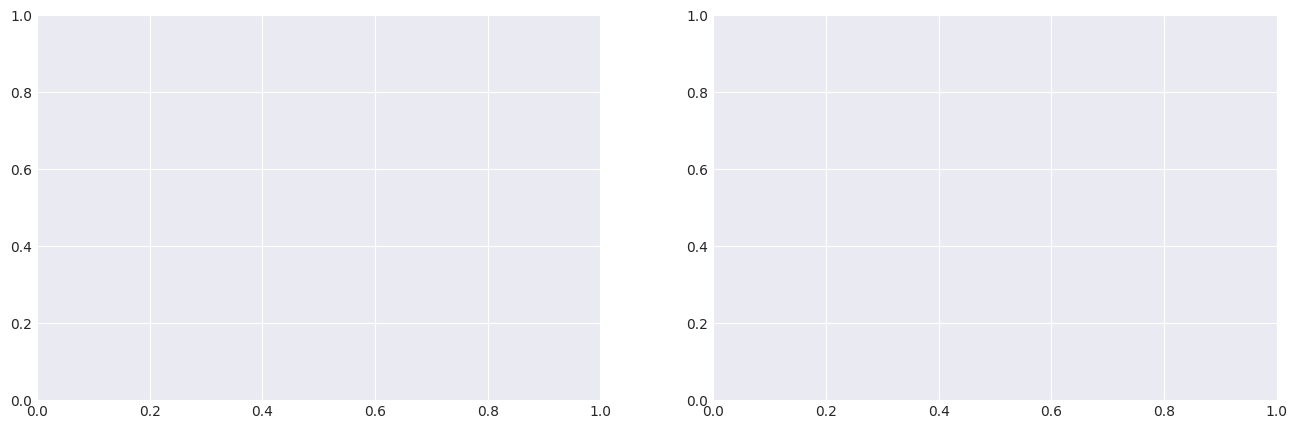

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gauche: OTM comparison
ax = axes[0]
for name, r in otm_results.items():
    ax.plot(r['cum'].values, label=f"OTM {name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('OTM Threshold Optimal', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Droite: VIX range comparison
ax = axes[1]
for name, r in vix_results.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('Filtre VIX', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('wheel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé.")

## 9. Conclusions et recommandations

### Résumé

| Métrique | Meilleure config |
|----------|-----------------|
| OTM | (à remplir) |
| DTE | (à remplir) |
| VIX Range | (à remplir) |
| Sharpe | (à remplir) |
| CAGR | (à remplir) |

### Verdict

Si Sharpe > 0.8: **Déployer avec les paramètres optimaux**

### Points forts Option Wheel

- **Revenu régulier**: Premiums des puts et calls
- **Adaptatif**: S'adapte automatiquement (cash vs invested)
- **VIX filter**: Évite les périodes de volatilité extrême
- **Exposition limitée**: Max 80% du portefeuille

### Limitations

- **Complexité**: Gestion des deux phases (put/call)
- **Risque d'assignment**: Peut être assigné sur les puts
- **Revenu plafonné**: Premium limité par OTM et VIX

### Prochaines étapes

1. Déployer sur QC cloud avec les paramètres optimaux
2. Tester sur d'autres sous-jacents (QQQ, IWM)
3. Optimiser le roll (avant expiration pour éviter assignment)
4. Combiner avec stratégie Covered Call pour plus de revenus